In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import scipy.sparse as sp
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load datasets
books = pd.read_csv('Books.csv')
books_cat = pd.read_csv('Books_categories.csv', encoding='latin-1')

In [4]:
# Drop missing values and duplicates
books_cat = books_cat.dropna(subset=['text_clean', 'keyword_category'])
books_cat = books_cat.drop_duplicates(subset=['Title'])
books_cat = books_cat.reset_index(drop=True)

print(f"Dataset shape after cleaning: {books_cat.shape}")
print(f"\nGenre distribution:\n{books_cat['keyword_category'].value_counts().head(10)}")

Dataset shape after cleaning: (1985, 7)

Genre distribution:
keyword_category
other         539
fiction       401
history       287
military      243
travel        206
romantic      135
medical        52
business       42
scientific     35
psychology     33
Name: count, dtype: int64


In [5]:
# TF-IDF vectorization on cleaned book descriptions
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(books_cat['text_clean'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (1985, 5000)


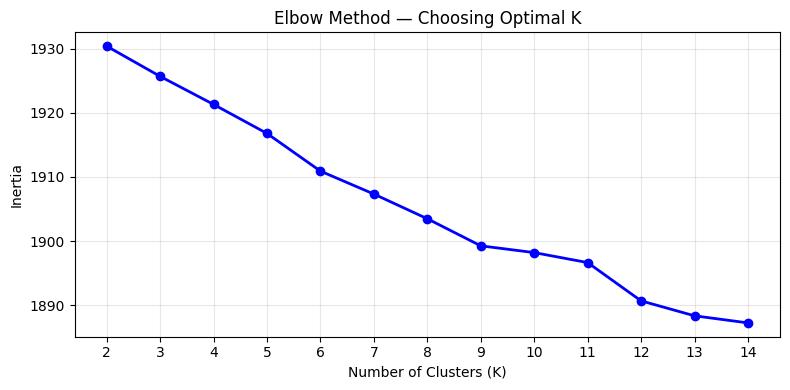

In [6]:
# Elbow method to determine optimal K
inertia = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

In [7]:
# Train K-Means with K=6 (selected based on elbow plot)
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
books_cat['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f"Books per cluster:\n{books_cat['cluster'].value_counts().sort_index()}")

Books per cluster:
cluster
0     94
1    210
2    408
3    493
4    752
5     28
Name: count, dtype: int64


In [8]:
# Top keywords per cluster
feature_names = tfidf.get_feature_names_out()
cluster_centers = kmeans.cluster_centers_

for i in range(K):
    top_indices = cluster_centers[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"Cluster {i}: {', '.join(top_words)}")

Cluster 0: vampire, harry, sookie, zoey, anita, night, dresden, wizard, undead, harry dresden
Cluster 1: new, new york, york, time, york time, life, bestselling, time bestselling, one, city
Cluster 2: book, story, tale, classic, reader, adventure, first, world, one, edition
Cluster 3: life, family, story, love, novel, year, one, woman, two, young
Cluster 4: one, life, world, know, year, find, never, love, even, secret
Cluster 5: stephanie, de, plum, la, stephanie plum, bounty hunter, bounty, ranger, morelli, hunter


In [9]:
# Export outputs for teammates
books_cat.to_csv('books_with_clusters.csv', index=False)
sp.save_npz('tfidf_matrix.npz', tfidf_matrix)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_books_by_description(input_text, top_n=5):
    """
    Given a text description, find the most similar books
    using cosine similarity on TF-IDF vectors.
    """
    input_vector = tfidf.transform([input_text])
    sim_scores = cosine_similarity(input_vector, tfidf_matrix).flatten()
    top_indices = sim_scores.argsort()[-top_n:][::-1]

    results = books_cat.iloc[top_indices][['Title', 'keyword_category', 'cluster']].copy()
    results['similarity_score'] = sim_scores[top_indices].round(4)
    return results.reset_index(drop=True)

# Test
input_text = "A young wizard discovers his powers and enters a magical school."
recommend_books_by_description(input_text, top_n=5)

,Title,keyword_category,cluster,similarity_score
0,"Sourcery (Discworld, #5; Rincewind #3)",other,4,0.1986
1,"Equal Rites (Discworld, #3; Witches #1)",other,4,0.1568
2,The Tales of Beedle the Bard,military,2,0.1560
3,The Name of the Wind (The Kingkiller Chronicle...,fiction,2,0.1511
4,"Proven Guilty (The Dresden Files, #8)",military,0,0.1324


In [11]:
from sklearn.metrics import silhouette_score
score = silhouette_score(tfidf_matrix, books_cat['cluster'], sample_size=500)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.0043
